# Regularization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset =pd.read_csv("Housing.csv")
dataset.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
dataset.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


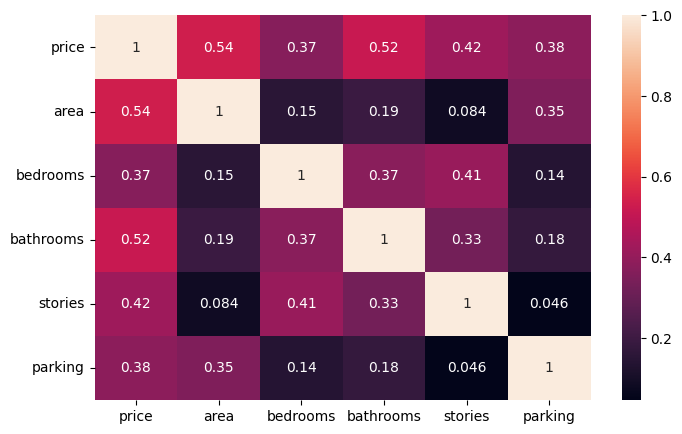

In [4]:
plt.figure(figsize=(8,5))
sns.heatmap(data = dataset.corr(numeric_only=True),annot=True)
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus"
]

for col in categorical_columns:
    dataset[col] = le.fit_transform(dataset[col])

In [8]:
X = dataset.drop("price",axis=1)
y = dataset["price"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
print("Ridge Score:", ridge.score(X_test, y_test))

Ridge Score: 0.6489858025515297


In [11]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
print("Lasso Score:", lasso.score(X_test, y_test))

Lasso Score: 0.6494747129728069


In [12]:
print("Ridge Coefficients")
print(ridge.coef_)

print("Lasso Coefficients")
print(lasso.coef_)

Ridge Coefficients
[ 2.37029858e+02  8.16398425e+04  1.08475439e+06  4.07899538e+05
  3.60673915e+05  2.32556086e+05  3.92904844e+05  6.52984924e+05
  7.75067212e+05  2.27245806e+05  6.21310182e+05 -2.11581614e+05]
Lasso Coefficients
[ 2.35849832e+02  7.85740019e+04  1.09711417e+06  4.06223696e+05
  3.66816428e+05  2.33141850e+05  3.93158954e+05  6.87858542e+05
  7.85545790e+05  2.25756363e+05  6.29897366e+05 -2.10397085e+05]
